# Demo — Predicting cardiac niches on Xenium5K data

This notebook walks through the **end-to-end TissueTypist workflow for
imaging-based ST**, using Xenium5K as the example query:

1. Inspect the Xenium5K query AnnData.
2. Check how much of the gene panel overlaps the cardiac shared-gene catalogue.
3. **Retrain** the hierarchical models on `panel ∩ shared_all` (~5–10 min).
4. Predict niche labels on the query using the panel-specific models.
5. Evaluate — spatial maps, UMAP, confidence distributions.

**Data used here.** 
- Xenium5K cardiac AnnData [Cranlay & Kanemaru et al., bioRxiv, 2025](https://www.biorxiv.org/content/10.1101/2024.04.29.591736v3)
   * You can download the dataset from our webportal [here](https://cellgeni.cog.sanger.ac.uk/heartcellatlas/foetal_webportal/Xenium-5K_raw.h5ad) (Xenium-5K_raw.h5ad)
   * substitute your own Xenium5K `.h5ad` by editing the `XENIUM5K_QUERY` path in the **Setup** cell below.

- Reference datasets for re-training.
   * The download links for the cardiac reference datasets will be made available at the time of manuscript publication.

## 1. Setup


In [3]:
Path.home()

PosixPath('/Users/kazumasakanemaru')

In [4]:
# Edit these four paths — everything else flows from them.
from pathlib import Path
import tissuetypist

REPO          = Path.home() / "GitHub" / "TissueTypist"   # repo root
XENIUM5K_QUERY = Path.home() / "GitHub" / "anndata" / "Xenium5K" / "Xenium-5K_raw.h5ad"
GENE_POOLS    = REPO / "results" / "phase0_pseudobulk" / "gene_pools.csv"
FULLGENOME    = tissuetypist.load_preset("default")

PANEL_OUTDIR  = Path.home() / "GitHub" / "anndata" / "Xenium5K" / "results" / "panel_Xenium5K_demo"     # this notebook will write here
EVAL_OUTDIR   = Path.home() / "GitHub" / "anndata" / "Xenium5K" / "results" / "eval_Xenium5K_demo"

for p in [XENIUM5K_QUERY, GENE_POOLS, FULLGENOME]:
    assert p.exists(), f"Missing prerequisite: {p}"

print("All prerequisites resolved.")

All prerequisites resolved.


In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import tissuetypist
print("TissueTypist version:", tissuetypist.__version__ if hasattr(tissuetypist, "__version__") else "(dev install)")
print("scanpy:", sc.__version__)


TissueTypist version: 0.1.0
scanpy: 1.12


## 2. Inspect the Xenium5K query

Loading the cell-level Xenium5K AnnData. For TissueTypist this needs:

- **Raw counts in `adata.X`** (no log-normalisation — TissueTypist handles
  this).
- **`obsm['spatial']`** — 2-D µm coordinates per cell.
- **`obs[section_col]`** — a section / library identifier; cells from
  different sections must not share coordinates.


In [6]:
adata = sc.read_h5ad(XENIUM5K_QUERY)
print(adata)
print()
print("Sections:", adata.obs["section_ID"].unique().tolist()
      if "section_ID" in adata.obs.columns
      else "(no `section_ID` column — set SECTION_COL below)")


AnnData object with n_obs × n_vars = 341592 × 5001
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'tissue_block_id', 'fine_grain_17Apr2026', 'coarse_grain_17Apr2026'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap_pca_harmony', 'spatial'
    varm: 'PCs'

Sections: (no `section_ID` column — set SECTION_COL below)


In [7]:
# Pick the section column. Most Xenium5K datasets ship a section label —
SECTION_COL = "tissue_block_id"

n_cells_per_section = adata.obs[SECTION_COL].value_counts()
print(n_cells_per_section)


tissue_block_id
Hst45-HEA-0-FFPE-1    206080
C194-HEA-0-FFPE-1     135512
Name: count, dtype: int64


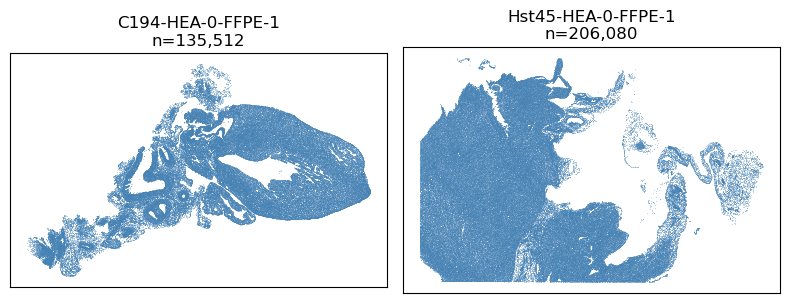

In [8]:
# Quick spatial sanity-plot — one panel per section, coloured by a
# reference marker. Shows that obsm['spatial'] is sane.
import matplotlib.pyplot as plt

sections = adata.obs[SECTION_COL].unique()
fig, axes = plt.subplots(1, len(sections), figsize=(4 * len(sections), 4),
                         squeeze=False)
for ax, sec in zip(axes[0], sections):
    sub = adata[adata.obs[SECTION_COL] == sec]
    ax.scatter(sub.obsm["spatial"][:, 0], sub.obsm["spatial"][:, 1],
               s=0.3, c="steelblue", alpha=0.4, linewidths=0)
    ax.set_title(f"{sec}\nn={sub.n_obs:,}")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


## 3. Gene panel overlap with the cardiac catalogue

The cardiac `shared_all` catalogue is the set of genes present across
all three reference modalities (SD 3′, SD FFPE, HD). Any gene in the
panel that's *not* in `shared_all` is dropped during retraining.


In [9]:
gene_pools = pd.read_csv(GENE_POOLS)
shared_all = set(gene_pools["shared_all"].dropna().astype(str))
panel      = set(adata.var_names)

overlap = panel & shared_all
print(f"Panel:       {len(panel):>6,} genes")
print(f"shared_all:  {len(shared_all):>6,} genes")
print(f"Overlap:     {len(overlap):>6,} genes ({100*len(overlap)/len(panel):.1f}% of panel)")
print(f"Panel-only (will be ignored): {len(panel - shared_all)} genes")


Panel:        5,001 genes
shared_all:  14,745 genes
Overlap:      4,191 genes (83.8% of panel)
Panel-only (will be ignored): 810 genes


## 4. Retrain on the panel

We use **strategy 1: pre-computed gene lists from a prior full-genome
training**. Each stage takes its existing gene list (e.g. the coarse
model's 6,292 genes) and intersects it with the panel — typically
yielding ~200 genes per stage on a 238-gene Xenium5K panel.

Other strategies covered in [docs/user-guide.md](../user-guide.md):

- *Fresh DEG+HVG on panel-normalised data* — drop `--gene_lists_from`,
  add `--feature_set deg_hvg` (the default).
- *Custom curated gene list* — pass `--custom_gene_list path/to/markers.txt`.

Wall time on a 2024 Mac with 3-section Xenium5K: ~8 minutes.


In [16]:
%%time
import shutil, subprocess, sys
from pathlib import Path

TT = str(Path(sys.executable).parent / "tissuetypist")

if PANEL_OUTDIR.exists():
    print(f"Found existing trained models at {PANEL_OUTDIR} — skipping retraining.")
    print("Delete that directory if you want to re-run training from scratch.")
else:
    cmd = [
        TT, "train-panel",
        "--query",               str(XENIUM5K_QUERY),
        "--query_section_col",   str(SECTION_COL),    # the column which has section IDs
        "--reference",           str(REPO / "data" / "adata_sd_3p_raw.h5ad"),
        "--reference_secondary", str(REPO / "data" / "adata_sd_ffpe_raw.h5ad"),
        "--reference_tertiary",  str(REPO / "data" / "adata_hd_windows.h5ad"),
        "--gene_pools",          str(GENE_POOLS),
        "--gene_lists_from",     str(FULLGENOME),
        "--outdir",              str(PANEL_OUTDIR),
    ]
    print("$ " + " \\\n    ".join(cmd))
    subprocess.run(cmd, check=True)

$ /opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/bin/tissuetypist \
    train-panel \
    --query \
    /Users/kazumasakanemaru/GitHub/anndata/Xenium5K/Xenium-5K_raw.h5ad \
    --query_section_col \
    tissue_block_id \
    --reference \
    /Users/kazumasakanemaru/GitHub/TissueTypist/data/adata_sd_3p_raw.h5ad \
    --reference_secondary \
    /Users/kazumasakanemaru/GitHub/TissueTypist/data/adata_sd_ffpe_raw.h5ad \
    --reference_tertiary \
    /Users/kazumasakanemaru/GitHub/TissueTypist/data/adata_hd_windows.h5ad \
    --gene_pools \
    /Users/kazumasakanemaru/GitHub/TissueTypist/results/phase0_pseudobulk/gene_pools.csv \
    --gene_lists_from \
    /Users/kazumasakanemaru/GitHub/TissueTypist/tissuetypist/models/default \
    --outdir \
    /Users/kazumasakanemaru/GitHub/anndata/Xenium5K/results/panel_Xenium5K_demo
20:35:01 [INFO] tissuetypist.cli — Logging to file: /Users/kazumasakanemaru/GitHub/anndata/Xenium5K/results/panel_Xenium5K_demo/training_2026-07-29_203501.log


... storing 'tissue_block_id' as categorical


### Total window number ###: 21222
### Average cell number per window ###: 16.1
Pseudobulk: summed per window and log-normalised.
20:35:24 [INFO] tissuetypist.cli —   query windows → /Users/kazumasakanemaru/GitHub/anndata/Xenium5K/results/panel_Xenium5K_demo/query_windows.h5ad
20:35:25 [INFO] tissuetypist.cli —   query cell→window mapping → /Users/kazumasakanemaru/GitHub/anndata/Xenium5K/results/panel_Xenium5K_demo/query_cell_window_assignment.csv.gz
20:35:26 [INFO] tissuetypist.training.hierarchical — Loading gene pools from CSV: /Users/kazumasakanemaru/GitHub/TissueTypist/results/phase0_pseudobulk/gene_pools.csv
20:35:26 [INFO] tissuetypist.training.hierarchical —   gene pool: 14745 genes
20:35:26 [INFO] tissuetypist.cli — Hierarchy: 'cardiac_Apr2026' (strategy='pre_computed')
20:35:26 [INFO] tissuetypist.training.panel_specific — Gene panel overlap: 5001 panel × 14745 shared_all → 4191 overlap (83.8% of panel, 810 panel-only genes ignored)
20:35:26 [INFO] tissuetypist.training.panel

/Users/kazumasakanemaru/GitHub/TissueTypist/tissuetypist/features/spatial.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for section, group_df in data.groupby('section'):


20:35:31 [INFO] tissuetypist.features.spatial — SD: annotating edges (tile_type=square)...
20:35:32 [INFO] tissuetypist.features.spatial — SD neighbourhood complete: 19179 spots × 8389 columns
20:35:32 [INFO] tissuetypist.training.hierarchical —   Building SD FFPE neighbourhood features (18234 spots, 4191 genes)...
20:35:32 [INFO] tissuetypist.features.spatial — SD neighbourhood: 4191 / 4191 genes found in adata
20:35:32 [INFO] tissuetypist.features.spatial — SD: computing neighbour-max (k=6)...


/Users/kazumasakanemaru/GitHub/TissueTypist/tissuetypist/features/spatial.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for section, group_df in data.groupby('section'):


20:35:32 [INFO] tissuetypist.features.spatial — SD: annotating edges (tile_type=square)...
20:35:33 [INFO] tissuetypist.features.spatial — SD neighbourhood complete: 18234 spots × 8389 columns
20:35:33 [INFO] tissuetypist.training.hierarchical —   Building HD neighbourhood features (9583 windows, 4191 genes)...
20:35:33 [INFO] tissuetypist.features.spatial — HD neighbourhood: 4191 / 4191 genes found in adata_windows
20:35:33 [INFO] tissuetypist.features.spatial — HD: computing neighbour-max (k=6)...


/Users/kazumasakanemaru/GitHub/TissueTypist/tissuetypist/features/spatial.py:359: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for section, group_df in data.groupby('section'):


20:35:34 [INFO] tissuetypist.features.spatial — HD: annotating edges (tile_type=square)...
20:35:34 [INFO] tissuetypist.features.spatial — HD neighbourhood complete: 9583 windows × 8389 columns
20:35:35 [INFO] tissuetypist.training.hierarchical —   Combined feature matrix: 46996 rows × 8391 columns
20:35:35 [INFO] tissuetypist.training.hierarchical — 
20:35:35 [INFO] tissuetypist.training.hierarchical — STAGE 1: Coarse model (7-class)
20:35:35 [INFO] tissuetypist.training.hierarchical — ======================================================================
20:35:35 [INFO] tissuetypist.training.hierarchical — Coarse: using override gene list (2175 genes, 2175 ∩ shared_all)
20:35:35 [INFO] tissuetypist.training.hierarchical — Subsetting coarse neighbourhood features...
20:35:35 [INFO] tissuetypist.training.hierarchical — Coarse training data: 46996 spots, 7 classes: ['AV junction', 'Atrium', 'Epicardial region', 'Lymph node', 'Pacemaker conduction system', 'Vasculature', 'Ventricle']
20:

In [17]:
# Inspect what was produced.
for p in sorted(PANEL_OUTDIR.iterdir()):
    print(f"  {p.name:<45}  {p.stat().st_size/1024:.1f} KB")


  atrium_lr_gene_list.txt                        16.0 KB
  atrium_lr_pipeline.joblib                      460.8 KB
  atrium_split_gene_list.txt                     15.0 KB
  atrium_split_pipeline.joblib                   432.9 KB
  atrium_transitional_gene_list.txt              9.9 KB
  atrium_transitional_pipeline.joblib            287.8 KB
  avjunction_gene_list.txt                       15.8 KB
  avjunction_pipeline.joblib                     454.9 KB
  coarse_gene_list.txt                           12.7 KB
  coarse_pipeline.joblib                         572.5 KB
  gene_counts.csv                                0.2 KB
  hierarchy_config.json                          7.3 KB
  pcs_sinoatrial_gene_list.txt                   9.1 KB
  pcs_sinoatrial_pipeline.joblib                 313.8 KB
  pcs_split_gene_list.txt                        12.5 KB
  pcs_split_pipeline.joblib                      362.0 KB
  query_cell_window_assignment.csv.gz            1851.5 KB
  query_windows.h5ad      

In [18]:
# `training_summary.csv` reports per-stage gene counts after panel intersection.
pd.read_csv(PANEL_OUTDIR / "training_summary.csv")


,model,stage,n_spots,n_classes,n_genes,modalities
0,coarse,1,46996,7,2175,"SD_3prime, SD_FFPE, HD_FFPE"
1,ventricle,2,31311,5,2469,"SD_3prime, SD_FFPE, HD_FFPE"
2,avjunction,2,2088,2,2687,"SD_3prime, SD_FFPE, HD_FFPE"
3,atrium_split,2a,4690,2,2555,"SD_3prime, SD_FFPE, HD_FFPE"
4,atrium_transitional,2b,4235,2,1695,HD_FFPE
5,atrium_lr,2c,4135,2,2719,"SD_3prime, SD_FFPE, HD_FFPE"
6,pcs_split,2a,721,2,2134,"SD_3prime, HD_FFPE"
7,pcs_sinoatrial,2b,295,3,1559,HD_FFPE
8,vasc_split,2a,6214,3,2508,"SD_3prime, SD_FFPE, HD_FFPE"
9,vasc_fine,2b,4016,2,2155,"SD_3prime, HD_FFPE"


## 5. Predict niche labels

For cell-level imaging-based ST, the prediction pipeline is:

1. **Pseudobulk cells into sliding windows** (~50 µm spots) — TissueTypist
   ships `sliding_window_pseudobulk_cells` for this. The panel-specific
   trainer in step 4 already produced a windowed copy of the query at
   `query_windows.h5ad`, so we'll reuse that here.
2. **Run `predict_adata` on the windows** with `modality="hd"` — the
   prediction reads the YAML hierarchy spec from the model dir, so
   nothing else needs to be passed.


In [19]:
# The retrainer already pseudobulked the cells when reading the query.
# Reuse those windows so we don't duplicate the work.
windows_path = PANEL_OUTDIR / "query_windows.h5ad"
adata_windows = sc.read_h5ad(windows_path)

# `tissuetypist train-panel` writes window centroids to obs columns but not
# to obsm['spatial']. The downstream plot helpers want obsm['spatial'], so
# restore it from `window_col` / `window_row`. Drop this once the CLI is
# updated to call `sliding_window_pseudobulk_cells` (which sets obsm itself).
if "spatial" not in adata_windows.obsm:
    adata_windows.obsm["spatial"] = (
        adata_windows.obs[["window_col", "window_row"]]
        .to_numpy(dtype=float)
    )

print(adata_windows)


AnnData object with n_obs × n_vars = 21222 × 5001
    obs: 'sliding_window_assignment', 'n_obs_aggregated', 'tissue_block_id', 'window_col', 'window_row'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'sum'


In [20]:
from tissuetypist import predict_adata

adata_windows = predict_adata(
    adata_windows,
    model_dir   = str(PANEL_OUTDIR),
    modality    = "hd",          # Xenium5K windows are aggregated like HD pseudobulk
    section_col = SECTION_COL,
)

# What did we get?
tt_cols = [c for c in adata_windows.obs.columns if c.startswith("tt_")]
print(f"Added {len(tt_cols)} tt_* columns.")
adata_windows.obs[[c for c in tt_cols if c in {
    'tt_coarse_label', 'tt_coarse_score',
    'tt_fine_label',   'tt_fine_score',
    'tt_joint_score',  'tt_final_label', 'tt_low_conf',
}]].head()


Added 27 tt_* columns.


,tt_coarse_label,tt_coarse_score,tt_fine_label,tt_fine_score,tt_joint_score,tt_final_label,tt_low_conf
Hst45-HEA-0-FFPE-1_window_11,Epicardial region,0.741488,NaN,NaN,NaN,Epicardial region,False
Hst45-HEA-0-FFPE-1_window_12,Ventricle,0.711915,Ventricle - Compact,0.999825,0.711790,Ventricle - Compact,False
Hst45-HEA-0-FFPE-1_window_13,Ventricle,0.996932,Ventricle - Compact,0.996737,0.993679,Ventricle - Compact,False
Hst45-HEA-0-FFPE-1_window_14,Ventricle,0.998455,Ventricle - Compact,0.999920,0.998375,Ventricle - Compact,False
Hst45-HEA-0-FFPE-1_window_15,Ventricle,0.996427,Ventricle - Compact,0.999955,0.996381,Ventricle - Compact,False


> ℹ️ **Mapping window predictions back to individual cells.** If you
> want a `tt_final_label` on every original cell (not just on each
> window), pass `hd_windows=adata_windows` and
> `sliding_window_col="window_id"` to `predict_adata` while passing the
> *raw cell-level AnnData* as the first argument. See the
> docstring of `predict_adata` for the full signature.


## 6. Visualise predictions

The plotting helpers in `tissuetypist.evaluation` operate directly on a
predicted AnnData, so we reuse `adata_windows` from the previous step
and don't re-run prediction. Each helper writes a single PDF to
`EVAL_OUTDIR` and uses the YAML's palette for niche colours.

> **Shortcut.** `tissuetypist.evaluation.evaluate(adata, model_dir, outdir,
> modality, prefix, ...)` is a one-shot wrapper that runs prediction
> *and* every plot below. Equivalent to the next cells, in a single
> call. We unpack it here so each step is visible.

> **Ground truth.** If `obs` carries cell-level reference labels, pass that column name to the helpers below
> as `fine_col=...` and TissueTypist will additionally produce a
> confusion matrix and classification report. We skip it here because
> Xenium5K queries typically lack ground truth.


In [21]:
from tissuetypist.evaluation.metrics import save_prediction_summary
from tissuetypist.evaluation.plots import (
    plot_confidence_distributions,
    plot_umap,
)
from tissuetypist.prediction.hierarchical import _load_hierarchy

EVAL_OUTDIR.mkdir(parents=True, exist_ok=True)
spec = _load_hierarchy(PANEL_OUTDIR)["spec"]   # palette + label order live here

# Per-niche summary CSV — counts + mean confidence per predicted leaf.
save_prediction_summary(adata_windows, fine_col=spec.fine_col,
                        outdir=EVAL_OUTDIR, prefix="Xenium5K", spec=spec)

# Save the predicted AnnData so downstream analysis can pick up here.
adata_windows.write_h5ad(EVAL_OUTDIR / "Xenium5K_predicted.h5ad")

print("Wrote:")
for p in sorted(EVAL_OUTDIR.iterdir()):
    print(f"  {p.name}")


Wrote:
  Xenium5K_predicted.h5ad
  Xenium5K_prediction_summary.csv


In [22]:
palette = {
    'Atrium - Left': '#1f77b4',
    'Atrium - Right': '#ff7f0e',
    'Atrium - Transitional': '#2ca02c',

    'Sinus horn': '#d62728',
    'SA node - Head': '#9467bd',
    'SA node - Tail': '#8c564b',
    'AV nodal region': '#e377c2',

    'Endocardial cushion - Valve': '#7f7f7f',

    'Ventricle - Compact': '#bcbd22',
    'Ventricle - Trabeculated': '#17becf',

    'VCS - Proximal': '#aec7e8',
    'VCS - Distal': '#ffbb78',

    'Endocardium - Atrial': '#c7e9c0',
    'Endocardium - Ventricular': '#98df8a',

    'Great vessel': '#ff9896',
    'Ductus arteriosus': '#c5b0d5',
    'Coronary vessel': '#c49c94',

    'Connective tissue': '#f7b6d2',
    'Epicardial region': '#c7c7c7',
    'Lymph node': '#9edae5',

    'Atrial myocardium': '#1f77b4',
    'Sinoatrial region': '#d62728',   # same as Sinus horn (region-level proxy)
}

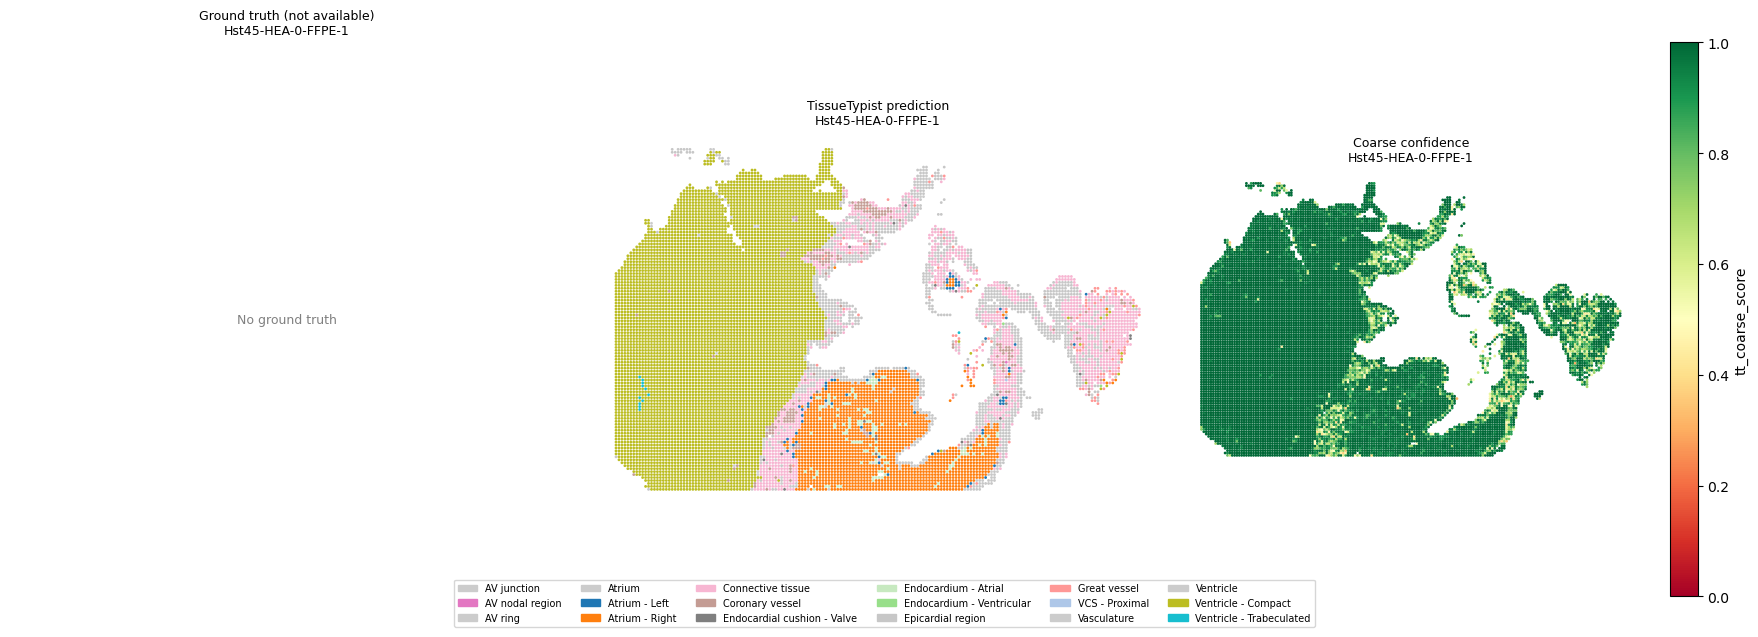

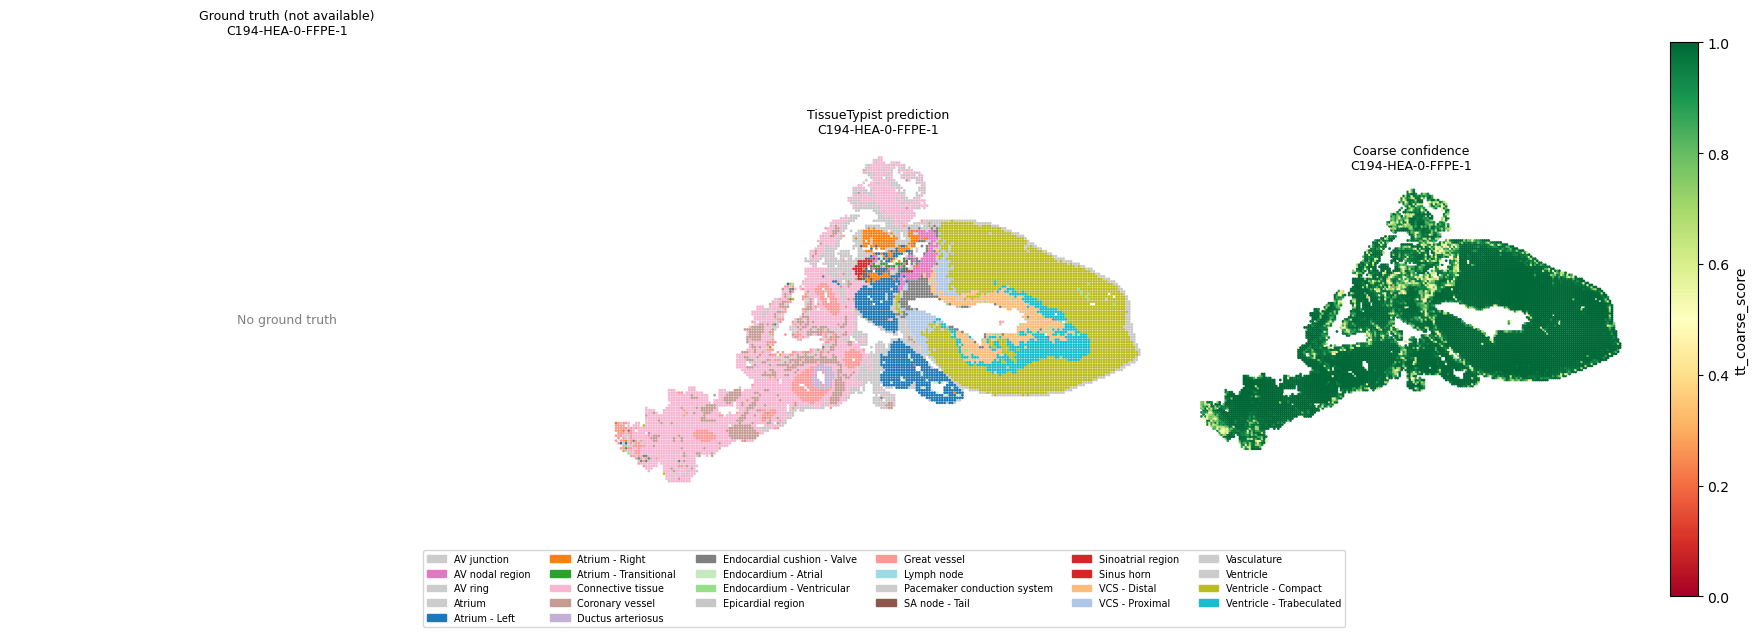

In [23]:
# Spatial panels — inline (one figure per section: GT | prediction | confidence).
# This is the inline equivalent of `tissuetypist.evaluation.plots.plot_spatial`,
# which always writes a PDF.
import matplotlib.patches as mpatches
from tissuetypist.evaluation.plots import build_palette_from_spec

has_gt = spec.fine_col in adata_windows.obs.columns
all_labels = sorted(
    (set(adata_windows.obs[spec.fine_col].dropna().astype(str).unique()) if has_gt else set())
    | set(adata_windows.obs["tt_final_label"].dropna().astype(str).unique())
)
# palette = build_palette_from_spec(spec, labels=all_labels)

n_sections_to_plot = 3
sections = list(adata_windows.obs[SECTION_COL].unique())[:n_sections_to_plot]

for section in sections:
    sub = adata_windows[adata_windows.obs[SECTION_COL] == section]
    xy  = sub.obsm["spatial"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # GT panel
    if has_gt:
        labels  = sub.obs[spec.fine_col].astype(str).values
        colours = [palette.get(l, "#cccccc") for l in labels]
        axes[0].scatter(xy[:, 0], xy[:, 1], c=colours, s=4, linewidths=0)
        axes[0].set_title(f"Ground truth\n{section}", fontsize=9)
    else:
        axes[0].text(0.5, 0.5, "No ground truth",
                     transform=axes[0].transAxes, ha="center", va="center",
                     fontsize=9, color="grey")
        axes[0].set_title(f"Ground truth (not available)\n{section}", fontsize=9)
    axes[0].set_aspect("equal"); axes[0].axis("off")

    # Prediction panel
    labels  = sub.obs["tt_final_label"].astype(str).values
    colours = [palette.get(l, "#cccccc") for l in labels]
    axes[1].scatter(xy[:, 0], xy[:, 1], c=colours, s=4, linewidths=0)
    axes[1].set_title(f"TissueTypist prediction\n{section}", fontsize=9)
    axes[1].set_aspect("equal"); axes[1].axis("off")

    # Coarse confidence panel
    scores = sub.obs["tt_coarse_score"].values.astype(float)
    sc_plot = axes[2].scatter(
        xy[:, 0], xy[:, 1], c=scores, cmap="RdYlGn", vmin=0, vmax=1,
        s=4, linewidths=0,
    )
    plt.colorbar(sc_plot, ax=axes[2], label="tt_coarse_score")
    axes[2].set_title(f"Coarse confidence\n{section}", fontsize=9)
    axes[2].set_aspect("equal"); axes[2].axis("off")

    legend_labels = sorted(set(
        sub.obs[spec.fine_col].dropna().astype(str).unique() if has_gt
        else sub.obs["tt_final_label"].dropna().astype(str).unique()
    ))
    handles = [mpatches.Patch(color=palette.get(l, "#cccccc"), label=l)
               for l in legend_labels]
    fig.legend(handles=handles, loc="lower center",
               ncol=min(6, len(legend_labels)),
               fontsize=7, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()

In [24]:
# UMAP + confidence distributions — kept as PDF (single figures, less to gain
# from inlining). Swap in `plt.show()` versions if you'd rather see them inline.
plot_umap(adata_windows, fine_col=spec.fine_col, outdir=EVAL_OUTDIR,
          prefix="Xenium5K", spec=spec, n_pcs=30)
plot_confidence_distributions(adata_windows, outdir=EVAL_OUTDIR,
                              prefix="Xenium5K")

print("PDFs written to", EVAL_OUTDIR)
for p in sorted(EVAL_OUTDIR.glob("Xenium5K_*.pdf")):
    print(f"  {p.name}")

PDFs written to /Users/kazumasakanemaru/GitHub/anndata/Xenium5K/results/eval_Xenium5K_demo
  Xenium5K_confidence_distributions.pdf
  Xenium5K_umap.pdf


In [25]:
# Per-niche summary CSV
pd.read_csv(EVAL_OUTDIR / "Xenium5K_prediction_summary.csv")

,tt_final_label,n_spots,mean_coarse_score,mean_joint_score,n_low_conf
0,Ventricle - Compact,8889,0.989890,0.979949,0
1,Connective tissue,3747,0.916573,0.849889,0
2,Epicardial region,2442,0.871353,NaN,61
3,Atrium - Right,1841,0.962325,0.857547,0
4,Coronary vessel,778,0.965307,0.823107,0
5,Atrium - Left,751,0.942019,0.879363,0
6,Great vessel,580,0.910089,0.739514,34
7,Ventricle - Trabeculated,527,0.998410,0.871003,0
8,VCS - Distal,434,0.979479,0.923522,0
9,VCS - Proximal,230,0.976199,0.865755,0


## 7. Interpreting confidence

Every TissueTypist prediction carries three confidence scores:

| Column | Meaning |
|---|---|
| `tt_coarse_score` | Stage-1 (coarse-niche) classifier confidence. |
| `tt_fine_score` | Confidence of the deepest sub-model stage that ran. |
| `tt_joint_score` | Product of every stage's confidence — useful as a single threshold. |

When a sub-model's confidence falls below θ = 0.5, the chain walker
*stops* descending and writes the parent intermediate (e.g.
`Atrial myocardium`, `Sinoatrial region`, `Great vessels`) into
`tt_final_label`. These intermediate labels indicate "I know it's
in this region, but I can't resolve the leaf" — they are not failures.

See [docs/output-columns.md](../output-columns.md) for the full schema.


In [26]:
# How many windows fell back to an intermediate?
fallback_classes = {"Atrial myocardium", "Sinoatrial region", "Great vessels"}
mask = adata_windows.obs["tt_final_label"].isin(fallback_classes)
print(f"Windows resolved to a fallback intermediate: "
      f"{mask.sum()} / {adata_windows.n_obs} ({100*mask.mean():.1f}%)")

print()
print("Coarse niche distribution:")
print(adata_windows.obs["tt_coarse_label"].value_counts())


Windows resolved to a fallback intermediate: 1 / 21222 (0.0%)

Coarse niche distribution:
tt_coarse_label
Ventricle                      10175
Vasculature                     5314
Atrium                          2809
Epicardial region               2442
AV junction                      272
Pacemaker conduction system      209
Lymph node                         1
Name: count, dtype: int64


## 8. Project the prediction outputs to original adata

In [27]:
import pandas as pd
from tissuetypist import predict_adata

# 1. Load the cell→window mapping written by `tissuetypist train-panel`.
mapping = pd.read_csv(
    PANEL_OUTDIR / "query_cell_window_assignment.csv.gz",
    index_col=0,
)
adata.obs["sliding_window_assignment"] = mapping["sliding_window_assignment"]

# 2. Project window-level predictions onto cells — predict_adata handles the
#    window-id lookup internally when sliding_window_col is provided.
adata = predict_adata(
    adata,
    model_dir   = str(PANEL_OUTDIR),
    modality    = "hd",
    section_col = SECTION_COL,
    hd_windows  = adata_windows,
    sliding_window_col = "sliding_window_assignment",
)

# 3. Coverage check + save.
n_unmapped = adata.obs["tt_final_label"].isna().sum()
print(
    f"Projected {len(adata) - n_unmapped:,} / {len(adata):,} cells "
    f"({100 * (1 - n_unmapped / len(adata)):.1f}%). "
    f"{n_unmapped:,} cells fell in dropped windows or outside the grid → NaN labels."
)

EVAL_OUTDIR.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(EVAL_OUTDIR / "Xenium5K_predicted_cells.h5ad")

Projected 341,592 / 341,592 cells (100.0%). 0 cells fell in dropped windows or outside the grid → NaN labels.


In [28]:
set(adata.obs["tt_final_label"])

{'AV junction',
 'AV nodal region',
 'AV ring',
 'Atrium',
 'Atrium - Left',
 'Atrium - Right',
 'Atrium - Transitional',
 'Connective tissue',
 'Coronary vessel',
 'Ductus arteriosus',
 'Endocardial cushion - Valve',
 'Endocardium - Atrial',
 'Endocardium - Ventricular',
 'Epicardial region',
 'Great vessel',
 'Lymph node',
 'Pacemaker conduction system',
 'SA node - Tail',
 'Sinoatrial region',
 'Sinus horn',
 'VCS - Distal',
 'VCS - Proximal',
 'Vasculature',
 'Ventricle',
 'Ventricle - Compact',
 'Ventricle - Trabeculated'}

[<Axes: title={'center': 'tt_final_label'}, xlabel='spatial1', ylabel='spatial2'>]

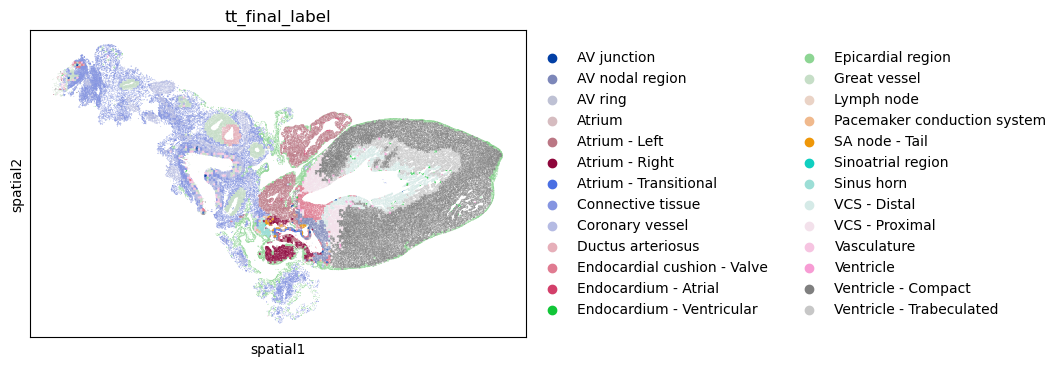

In [29]:
section_id = 'C194-HEA-0-FFPE-1'
slide = adata[adata.obs[SECTION_COL] == section_id].copy()

sc.pl.spatial(
                slide,
                color="tt_final_label",
                show=False,
                spot_size=15
            )